## Reduced model without AMPA, Wong and Wang 2006

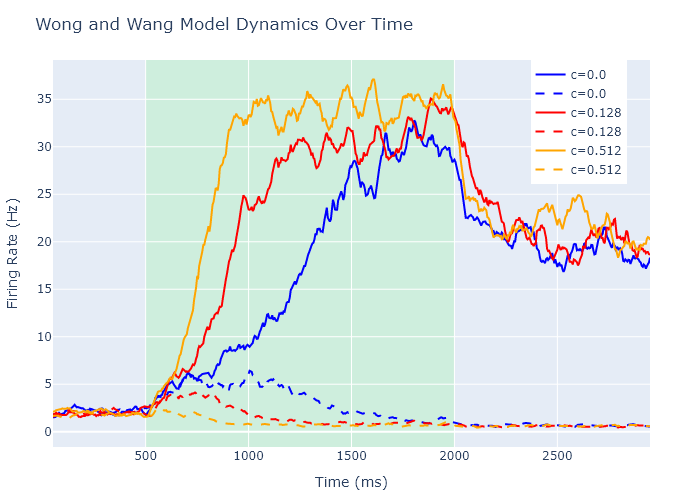

In [1]:
# Import necessary packages
using Random
using Statistics
using PlotlyJS

# Set random seed for reproducibility
Random.seed!(42)

# Simulation Parameters
dt = 0.5                        # Time step (ms)
t_max = 3000.0                  # Total simulation time (ms)
time = 0.0:dt:t_max             # Time vector
n_time_steps = length(time)

# Model Parameters
# Time Constants
τ_NMDA = 100.0                  # NMDA synaptic time constant (ms)
τ_AMPA = 2.0                    # AMPA synaptic time constant (ms)

# Synaptic Efficacies
J_N = 0.2609                    # Recurrent NMDA excitation strength
J_N_cross = 0.0497              # Cross NMDA excitation


# NMDA Gain Factor
γ = 0.641                       # NMDA receptor gain factor

# Define transfer function H(I)
# F-I Curve Parameters (Excitatory Neurons)
a = 270.0                       # (Hz/nA)
b = 108.0                       # (Hz)
d = 0.154                       # (s)
function H(I)
    I_eff = a * I - b
    #if I_eff <= 0
    #    return 0.0
    #else
        return I_eff / (1.0 - exp(-d * I_eff))
    #end
end

# External Inputs
I_0 = 0.3255                    # Baseline external input (nA)
μ0 = 30                         # Hz, mean input
J_Input = 5.2e-4                # Input excitation
coherences = [0.0, 0.128, 0.512]# Coherence level (0 to 1)
colors = ["blue", "red", "orange"]

stim_start = 500.0              # Stimulus onset time (ms)
stim_end = 2000.0               # Stimulus offset time (ms)

# Noise Parameters
σ_I = 0.02                      # Reduced standard deviation of input noise (nA)

traces = PlotlyJS.AbstractTrace[]
for i in 1:length(coherences)
    # Stimulus input to Population 1&2
    I_stim_1 = J_Input * μ0 * (1 + coherences[i]) 
    I_stim_2 = J_Input * μ0 * (1 - coherences[i])

    # Initialize variables
    S1 = zeros(n_time_steps)        # Synaptic gating variable for Population 1
    S2 = zeros(n_time_steps)        # Synaptic gating variable for Population 2

    r1 = zeros(n_time_steps)        # Firing rate of Population 1
    r2 = zeros(n_time_steps)        # Firing rate of Population 2

    I1 = zeros(n_time_steps)        # Total input current to Population 1
    I2 = zeros(n_time_steps)        # Total input current to Population 2

    decision_made = false
    decision_time = 0.0
    choice = 0

    # Precompute external inputs
    I_ext1 = fill(I_0, n_time_steps)
    I_ext2 = fill(I_0, n_time_steps)

    stim_indices = findall(t -> t >= stim_start && t <= stim_end, time)
    I_ext1[stim_indices] .+= I_stim_1
    I_ext2[stim_indices] .+= I_stim_2

    # Simulate the network dynamics
    I_noise1 = σ_I * randn()
    I_noise2 = σ_I * randn()

    S1[1] = S2[1] = 0.1
    for t in 1:n_time_steps-1
        
        # Compute noise terms
        I_noise1 = I_noise1 + dt / τ_AMPA * (-I_noise1) + sqrt(dt/τ_AMPA) * σ_I * randn()
        I_noise2 = I_noise2 + dt / τ_AMPA * (-I_noise2) + sqrt(dt/τ_AMPA) * σ_I * randn()

        # Compute total input currents
        I1[t] = J_N * S1[t] - J_N_cross * S2[t] + I_ext1[t] + I_noise1
        I2[t] = J_N * S2[t] - J_N_cross * S1[t] + I_ext2[t] + I_noise2
        
        # Compute firing rates
        r1[t] = H(I1[t])
        r2[t] = H(I2[t])
        r1[t] = r1[t] < 0 ? 0 : r1[t]
        r2[t] = r2[t] < 0 ? 0 : r2[t]
        
        # Update synaptic gating variables using Euler method with gamma_NMDA
        S1[t+1] = S1[t] + (- S1[t] / τ_NMDA + (1 - S1[t]) * γ * r1[t] / 1000) * dt
        S2[t+1] = S2[t] + (- S2[t] / τ_NMDA + (1 - S2[t]) * γ * r2[t] / 1000) * dt
        
    end


    # Calculate mean rates and gating variables with sliding window
    time_window = Int(50 / dt)                          # time window 50 ms
    sliding_step = Int(5 / dt)                          # sliding window step 5 ms
    r1_smooth = [mean(r1[1:time_window])]
    r2_smooth = [mean(r2[1:time_window])]
    S1_smooth = [mean(S1[1:time_window])]
    S2_smooth = [mean(S2[1:time_window])]
    for t in 1:Int(floor((n_time_steps - time_window) / sliding_step))
        start_idx = sliding_step * (t-1) + 1
        end_idx = sliding_step * (t-1) + time_window
        push!(r1_smooth, mean(r1[start_idx:end_idx]))
        push!(r2_smooth, mean(r2[start_idx:end_idx]))
        push!(S1_smooth, mean(S1[start_idx:end_idx]))
        push!(S2_smooth, mean(S2[start_idx:end_idx]))
    end

    # Visualization using PlotlyJS
    trace_r1 = scatter(
        x = dt*time_window:dt*sliding_step:dt*(n_time_steps - time_window),
        y = r1_smooth,
        mode = "lines",
        name = "c=$(coherences[i])",
        line = attr(color = colors[i], width = 2, dash=r1_smooth[length(r1_smooth)] < r2_smooth[length(r2_smooth)] ? "dash" : "solid")
    )

    trace_r2 = scatter(
        x = dt*time_window:dt*sliding_step:dt*(n_time_steps - time_window),
        y = r2_smooth,
        mode = "lines",
        name = "c=$(coherences[i])",
        line = attr(color = colors[i], width = 2, dash=r1_smooth[length(r1_smooth)] > r2_smooth[length(r2_smooth)] ? "dash" : "solid")
    )

    push!(traces, trace_r1)
    push!(traces, trace_r2)
end

# Create shape for stimulus period
stim_shape = [
    attr(
        type = "rect",
        xref = "x",
        yref = "paper",
        x0 = stim_start,
        y0 = 0,
        x1 = stim_end,
        y1 = 1,
        fillcolor = "rgba(0, 255, 0, 0.1)",
        line = attr(width = 0),
        layer = "below"
    )
]

# Create layout for time series plot
layout_time_series = Layout(
    title = "Wong and Wang Model Dynamics Over Time",
    xaxis = attr(title = "Time (ms)"),
    yaxis = attr(title = "Firing Rate (Hz)"),
    legend = attr(orientation = "v", x = 0.8, y = 1.0),
    shapes = stim_shape,
    height = 400
)

# Create figure for time series and display
fig_time_series = Plot(traces, layout_time_series)

display(fig_time_series)

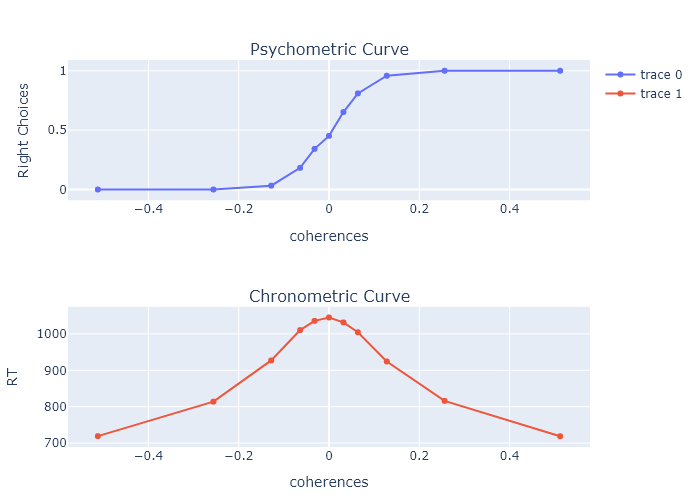

In [2]:
using Random
using Statistics
using PlotlyJS

time_non_decision = 0.3
threshold = 20
coherences = [-0.512, -.256, -.128, -.064, -.032, 0, +.032, +.064, +.128, +.256, +.512]
n_coherences = length(coherences)

total_trials = 10000

choices = []
rts = []
for coh in coherences
    push!(choices,[])
    push!(rts,[])
end

for trial in 1:total_trials
    coh_i = rand(1:n_coherences)
    coh = coherences[coh_i]
    # print(coh)
    
    # Stimulus input to Population 1&2
    I_stim_1 = J_Input * μ0 * (1 + coh) 
    I_stim_2 = J_Input * μ0 * (1 - coh)

    # Initialize variables
    S1 = 0.1        # Synaptic gating variable for Population 1
    S2 = 0.1        # Synaptic gating variable for Population 2

    r1 = 0.0        # Firing rate of Population 1
    r2 = 0.0        # Firing rate of Population 2

    I1 = 0.0        # Total input current to Population 1
    I2 = 0.0        # Total input current to Population 2

    decision_made = false
    decision_time = 0
    choice = 0

    # Precompute external inputs
    I_ext1 = fill(I_0, n_time_steps)
    I_ext2 = fill(I_0, n_time_steps)

    stim_indices = findall(t -> t >= stim_start && t <= stim_end, time)
    I_ext1[stim_indices] .+= I_stim_1
    I_ext2[stim_indices] .+= I_stim_2

    # Simulate the network dynamics
    I_noise1 = σ_I * randn()
    I_noise2 = σ_I * randn()

    while decision_time < n_time_steps && max(r1, r2) < threshold
        # Compute noise terms
        I_noise1 = I_noise1 + dt / τ_AMPA * (-I_noise1) + sqrt(dt/τ_AMPA) * σ_I * randn()
        I_noise2 = I_noise2 + dt / τ_AMPA * (-I_noise2) + sqrt(dt/τ_AMPA) * σ_I * randn()

        # Compute total input currents
        I1 = J_N * S1 - J_N_cross * S2 + I_ext1[decision_time + 1] + I_noise1
        I2 = J_N * S2 - J_N_cross * S1 + I_ext2[decision_time + 1] + I_noise2
        
        # Compute firing rates
        r1 = H(I1)
        r2 = H(I2)
        r1 = r1 < 0 ? 0 : r1
        r2 = r2 < 0 ? 0 : r2
        
        # Update synaptic gating variables using Euler method with gamma_NMDA
        S1 = S1 + (- S1 / τ_NMDA + (1 - S1) * γ * r1 / 1000) * dt
        S2 = S2 + (- S2 / τ_NMDA + (1 - S2) * γ * r2 / 1000) * dt

        decision_time = decision_time + 1
    end

    rt = decision_time * dt
    if r1 > r2
        choice = 1
    elseif r1 < r2
        choice = -1
    end

    if choice!=0 
        push!(choices[coh_i], choice/2+0.5)    # convert choice into 0 and 1
        push!(rts[coh_i], rt + time_non_decision)
    end
end

p_right=[]
rt=[]
for coh_i in 1:n_coherences
    if length(choices[coh_i])>0
        push!(p_right, mean(choices[coh_i]))
        push!(rt, mean(rts[coh_i]))
    else
        push!(p_right,-1)
        push!(rt,0)
    end
end

p1 = plot(coherences, p_right, Layout(title="Psychometric Curve",xaxis_title="coherences", yaxis_title="Right Choices"))
p2 = plot(coherences, rt, Layout(title="Chronometric Curve",xaxis_title="coherences", yaxis_title="RT"))
p = [p1; p2]